<a href="https://colab.research.google.com/github/devilistiani/coding_camp_copilot/blob/gabby/model_intent_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Install & Import Dependencies**

In [72]:
# REPRODUCIBILITY SETUP
"""
Menetapkan global random seed untuk memastikan hasil eksperimen konsisten di setiap kali notebook dijalankan ulang.
Seed dikunci sebelum import library lain agar tf.random dan np.random juga mengikuti seed yang sama.
"""

import random
import os

SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'


In [73]:
# LIBRARY IMPORTS & SEED PROPAGATION
"""
Mengimpor seluruh dependensi proyek:
- pandas / numpy   : Manipulasi data dan komputasi numerik
- re / json / os   : Utilitas standar Python
- tensorflow       : Framework Deep Learning utama
- sklearn          : Preprocessing, splitting, dan evaluasi model
Seed disebarkan ke numpy dan tensorflow untuk reproducibility penuh.
"""

import pandas as pd
import numpy as np
import re
import json
import os
import datetime

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pprint

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Tensorflow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Global seed set to: {SEED}")

Tensorflow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Global seed set to: 42


#**Load Dataset**

In [74]:
# LOAD DATASET
"""
Membaca dataset pertanyaan peserta Coding Camp dari file CSV.
Dataset berisi kolom: ID, Nama, Path, Pertanyaan, Jawaban, dan dua kolom
unnamed yang akan dibuang pada tahap cleaning.
Output: DataFrame mentah yang siap diperiksa strukturnya.
"""

file_path = '/content/Dataset Capstone Project - Sheet1.csv'
df = pd.read_csv(file_path)

print(f"Shape dataset: {df.shape}")
print(f"\Kolom: {df.columns.tolist()}")
df.head(5)

Shape dataset: (365, 7)
\Kolom: ['ID', 'Nama', 'Path', 'Pertanyaan', 'Jawaban', 'Unnamed: 5', 'Unnamed: 6']


<>:13: SyntaxWarning: invalid escape sequence '\K'
<>:13: SyntaxWarning: invalid escape sequence '\K'
/tmp/ipykernel_540/2684299135.py:13: SyntaxWarning: invalid escape sequence '\K'
  print(f"\Kolom: {df.columns.tolist()}")


,ID,Nama,Path,Pertanyaan,Jawaban,Unnamed: 5,Unnamed: 6
0,NaN,Siddiq_Febri,Data_Sains,"Permisi kak, saya mau nanya apakah boleh mengg...",gak disarankan sih kak soalnya saat program in...,NaN,Notes:
1,CACC319D6Y0511,Andre,full_stack developmen,"Halo semua, izin bertanya, apakah laporan tekn...","Berbeda ya, tapi mungkin saling beririsan",NaN,"Jika tidak ada informasi ID, isikan NA"
2,CFCC316D6Y1322,Jovan,ai_engineer,"Izin bertanya, kalau sudah mendaftarkan tim it...","Jika sudah mendaftar tim capstone, tim capston...",NaN,NaN
3,CFCC726D6Y0160,Alfito,ai_engineer,linimasa yang seperti ini si dimana ya?,Untuk linimasa reporting kampus bisa mengacu p...,NaN,NaN
4,CACC319D6Y0511,Andre,full_stack developmen,apakah PPT dari capstone briefing kemarin ada ...,Dokumen Playbook Capstone : https://docs.googl...,NaN,NaN


In [75]:
# INITIAL DATA FILTERING
"""
Mengekstrak kolom 'Pertanyaan' sebagai satu-satunya fitur input model.
Baris dengan nilai null atau string kosong dihapus untuk menghindari
noise pada proses tokenisasi dan labelling berikutnya.
"""

# Ambil kolom Pertanyaan
df_clean = df[['Pertanyaan']].dropna().copy()
df_clean = df_clean[df_clean['Pertanyaan'].str.strip() != '']

df = df.dropna(how='all')

df_clean = df_clean.reset_index(drop=True)
print(f"Total baris setelah cleaning: {len(df_clean)}")

Total baris setelah cleaning: 364


#**Text Preprocessing & Lexicon-Based Labelling**

In [76]:
# SLANG NORMALIZATION DICTIONARY & FUNCTION
"""
Kamus 141 entri yang memetakan kata informal/slang Bahasa Indonesia ke
bentuk bakunya (KBBI). Mencakup: sapaan, kata ganti informal, negasi,
dan ekspresi sehari-hari yang umum digunakan peserta Coding Camp.
Fungsi normalize_slang() mengutamakan pencocokan bigram (2 kata) sebelum
unigram untuk menangani frasa multi-kata (mis. 'amit amit' → 'buruk').
Kata yang dipetakan ke string kosong ('') akan dihapus dari teks.
"""

# Slang Dictionary
SLANG_DICT = {
    # Sapaan & filler
    'kak': '', 'kakak': '', 'min': '', 'bang': '', 'gan': '', 'bro': '',
    'halo': '', 'hai': '', 'hei': '', 'permisi': '', 'selamat': '', 'malam': '', 'pagi': '',
    'siang': '', 'sore': '', 'wkwk': '', 'wkwkwk': '', 'hehe': '', 'haha': '', 'hihi': '',
    'hehehe': '', 'dong': '', 'deh': '', 'sih': '', 'loh': '', 'lho': '', 'neh': '', 'si': '',

    # Kata ganti informal
    'aku': 'saya', 'gue': 'saya', 'gw': 'saya', 'sy': 'saya',
    'lo': 'anda', 'lu': 'anda', 'km': 'kamu',
    'kamu': 'anda', 'kalian': 'anda', 'kita': 'kami',

    # Negasi & penegasan informal
    'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak',
    'nggak': 'tidak', 'gk': 'tidak', 'tdk': 'tidak',
    'tak': 'tidak', 'yaa': 'ya', 'yap': 'ya', 'iyaa': 'iya',
    'oke': 'ok', 'oks': 'ok', 'okey': 'ok',

    # Kata kerja & ekspresi informal
    'nanya': 'bertanya', 'nanyain': 'menanyakan', 'gimana': 'bagaimana', 'gmn': 'bagaimana',
    'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah', 'uda': 'sudah', 'blm': 'belum', 'belom': 'belum',
    'blum': 'belum', 'dapet': 'dapat', 'dpt': 'dapat', 'tuh': 'itu', 'tu': 'itu', 'nih': 'ini',
    'ni': 'ini', 'kayak': 'seperti', 'kaya': 'seperti', 'kalo': 'kalau', 'klo': 'kalau', 'krn': 'karena',
    'karna': 'karena', 'krna': 'karena', 'emg': 'memang', 'emang': 'memang', 'aja': 'saja', 'aj': 'saja',
    'doang': 'saja', 'tp': 'tapi', 'tpi': 'tapi', 'ttg': 'tentang', 'yg': 'yang', 'yng': 'yang', 'lg': 'lagi',
    'lgi': 'lagi', 'jg': 'juga', 'jga': 'juga', 'dgn': 'dengan', 'dg': 'dengan', 'utk': 'untuk', 'bgt': 'banget',
    'bngt': 'banget', 'banget': 'sangat', 'bkn': 'bukan', 'dr': 'dari', 'dri': 'dari', 'kpn': 'kapan', 'knp': 'kenapa',
    'kenapa': 'mengapa', 'bikin': 'membuat', 'buat': 'membuat', 'mau': 'ingin', 'mo': 'ingin', 'pengen': 'ingin',
    'pengin': 'ingin', 'make': 'menggunakan', 'pake': 'menggunakan', 'pakai': 'menggunakan', 'ngelakuin': 'melakukan',
    'ngeliat': 'melihat', 'ngerti': 'mengerti', 'ngerasa': 'merasa', 'nyoba': 'mencoba', 'coba': 'mencoba', 'nyari': 'mencari',
    'cari': 'mencari', 'liat': 'lihat', 'lihat': 'melihat', 'tau': 'tahu', 'tw': 'tahu', 'kmrn': 'kemarin', 'kemaren': 'kemarin',
    'stlh': 'setelah', 'abis': 'setelah', 'habis': 'setelah', 'sehabis': 'setelah', 'abisnya': 'setelahnya', 'ntar': 'nanti', 'tar': 'nanti',

    # Lain-lain
    'kelar': 'selesai', 'beres': 'selesai', 'fix': 'pasti',
    'mantap': 'bagus', 'mantul': 'bagus', 'gacor': 'bagus',
    'bocil': 'pemula', 'gapapa': 'tidak apa',
    'gpp': 'tidak apa', 'amit amit': 'buruk',
}

def normalize_slang(text: str, slang_dict: dict = SLANG_DICT) -> str:
  """
  Normalisasi kata slang/informal.
  Bigram (2 kata) dicek lebih dulu sebelum unigram.
  Kata yang dipetakan ke '' akan dihapus.
  """
  words = text.split()
  normalized = []
  i = 0
  while i < len(words):
    # Cek bigram
    if i  + 1 < len(words):
      bigram = words[i] + ' ' + words[i + 1]
      if bigram in slang_dict:
        replacement = slang_dict[bigram]
        if replacement:
          normalized .append(replacement)
        i += 2
        continue
    # Unigram
    word = words[i]
    replacement = slang_dict.get(word, word)
    if replacement:
      normalized.append(replacement)
    i += 1
  return ' '.join(normalized)

print(f"Total entri SLANG_DICT: {len(SLANG_DICT)}")
print('\nContoh normalisasi slang:')
test_slang = [
    'halo kak, saya izin bertanya. untuk jadwal EN2 saya ingin melakukan reschedule. tetapi ketika mengisi kode sesi malah kayak gini padahal itu sudah benar',
    'Hallo kak, aku izin bertanya terkait dataset untuk capstone, apakah diperbolehkan menggunakan data sintesis atau dummy dari ai kak? soalnya udah nyari di kaggle dan website data lainnya nggak ketemu yang cocok, kalau ketemu yang cocok dikit juga',
    'kak saya mau tanya, jika ada kesalahan penulisan dosen pembimbing di dashboard codingcamp itu dapat melaporkannya kemana ya?  di LoA sudah benar namanya kak',
]
for s in test_slang:
  print(f' Input : {s}')
  print(f' Output: {normalize_slang(s)}')
  print()


Total entri SLANG_DICT: 141

Contoh normalisasi slang:
 Input : halo kak, saya izin bertanya. untuk jadwal EN2 saya ingin melakukan reschedule. tetapi ketika mengisi kode sesi malah kayak gini padahal itu sudah benar
 Output: kak, saya izin bertanya. untuk jadwal EN2 saya ingin melakukan reschedule. tetapi ketika mengisi kode sesi malah seperti gini padahal itu sudah benar

 Input : Hallo kak, aku izin bertanya terkait dataset untuk capstone, apakah diperbolehkan menggunakan data sintesis atau dummy dari ai kak? soalnya udah nyari di kaggle dan website data lainnya nggak ketemu yang cocok, kalau ketemu yang cocok dikit juga
 Output: Hallo kak, saya izin bertanya terkait dataset untuk capstone, apakah diperbolehkan menggunakan data sintesis atau dummy dari ai kak? soalnya sudah mencari di kaggle dan website data lainnya tidak ketemu yang cocok, kalau ketemu yang cocok dikit juga

 Input : kak saya mau tanya, jika ada kesalahan penulisan dosen pembimbing di dashboard codingcamp itu dapat

In [77]:
"""
STOP WORD REMOVAL
Mendefinisikan 128 stop word Bahasa Indonesia yang tidak mengandung makna
semantik penting untuk klasifikasi intent (kata hubung, kata depan, kata ganti, kata seru, dll.).
Fungsi remove_stop_words() menghapus token yang ada di daftar ini dan
token dengan panjang <= 1 karakter untuk mereduksi dimensi vocabulary.
"""

# Stop Words
STOP_WORDS = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'ini',
    'itu', 'atau', 'juga', 'ada', 'saya', 'kami', 'anda', 'kita', 'ia',
    'dia', 'mereka', 'adalah', 'akan', 'dapat', 'bisa', 'oleh',
    'dalam', 'sudah', 'telah', 'sedang', 'pun', 'lagi', 'saja', 'jadi',
    'kalau', 'jika', 'apakah', 'agar', 'hingga', 'sampai',
    'tentang', 'bahwa', 'maka', 'supaya', 'karena', 'sehingga', 'namun',
    'tetapi', 'tapi', 'melainkan', 'maupun', 'baik', 'bagi',
    'terhadap', 'antara', 'selama', 'setelah', 'sebelum', 'ketika',
    'saat', 'sewaktu', 'begitu', 'meskipun', 'walaupun', 'biarpun',
    'seperti', 'ibarat', 'seolah', 'serasa', 'seakan', 'sebagai',
    'tersebut', 'demikian', 'serta', 'hal', 'cara', 'lebih',
    'sangat', 'harus', 'perlu', 'tidak', 'belum', 'masih',
    'ingin', 'boleh', 'bukan', 'hanya', 'terlalu', 'paling',
    'setiap', 'semua', 'beberapa', 'banyak', 'sedikit', 'seluruh',
    'masing', 'tiap', 'lain', 'lainnya', 'dsb', 'dll', 'dst',
    'bagaimana', 'mengapa', 'kapan', 'siapa', 'dimana', 'kemana',
    'berapa', 'apapun', 'siapapun', 'dimanapun',
    'ya', 'ok', 'iya', 'oh', 'ow', 'eh', 'ah', 'ih', 'uh', 'hm',
    'nanti', 'kemarin', 'sekarang', 'nah', 'tadi', 'lalu', 'kemudian',
])

def remove_stop_words(text:  str, stop_words: set = STOP_WORDS) -> str:
  tokens = text.split()
  filtered = [w for w in tokens if w not in stop_words and len(w)> 1]
  return '  '.join(filtered)

print(f'Total stop words: {len(STOP_WORDS)}')
print('\nContoh hasil stop word removal:')
test_sw = [
    'Izin bertanya kak , ini kenapa pada bulan februari kemarin semua riwayat daily check in saya hilang ya?',
    'Permisi Kak. Untuk Financial Literasi 2 di dashboard sudah muncul, tapi statusnya masih absen. Padahal aku sudah submit abstraknya di malam hari yang sama, dan sudah lewat 3x24 jam tapi belum ada balasan email. Sebaiknya aku follow up lagi ya, Kak?'
]
for s in test_sw:
  print(f' Input : {s}')
  print(f' Output: {remove_stop_words(s)}')
  print()

Total stop words: 128

Contoh hasil stop word removal:
 Input : Izin bertanya kak , ini kenapa pada bulan februari kemarin semua riwayat daily check in saya hilang ya?
 Output: Izin  bertanya  kak  kenapa  bulan  februari  riwayat  daily  check  in  hilang  ya?

 Input : Permisi Kak. Untuk Financial Literasi 2 di dashboard sudah muncul, tapi statusnya masih absen. Padahal aku sudah submit abstraknya di malam hari yang sama, dan sudah lewat 3x24 jam tapi belum ada balasan email. Sebaiknya aku follow up lagi ya, Kak?
 Output: Permisi  Kak.  Untuk  Financial  Literasi  dashboard  muncul,  statusnya  absen.  Padahal  aku  submit  abstraknya  malam  hari  sama,  lewat  3x24  jam  balasan  email.  Sebaiknya  aku  follow  up  ya,  Kak?



In [78]:
"""
TEXT PREPROCESSING PIPELINE
Pipeline pembersihan teks end-to-end yang diterapkan secara berurutan:
1. Case folding        : Konversi teks ke huruf kecil
2. URL removal         : Menghapus tautan http/https dan www
3. Punctuation removal : Menghapus tanda baca non-alfanumerik
4. Digit removal       : Menghapus angka yang tidak bermakna semantis
5. Whitespace norm     : Normalisasi spasi ganda
6. Slang normalization : Menstandarkan kata informal ke bentuk baku
7. Stop word removal   : Menghapus kata-kata tidak bermakna
Kolom 'Pertanyaan_Clean' dibuat sebagai representasi teks siap model.
"""

# Text cleaning
def clean_text(text):
  # Case folding, hapus tanda baca, normalisasi space
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+', ' ', text) # hapus URL
  text = re.sub(r'[^\w\s]', ' ', text) # hapus tanda baca
  text = re.sub(r'\d+', ' ', text) # hapus angka
  text = re.sub(r'\s+', ' ', text).strip() # normalisasi spasi
  text = normalize_slang(text) # normalisasi slang
  text = remove_stop_words(text) # hapus stop words
  text = re.sub(r'\s+', ' ', text).strip() # normalisasi spasi akhir
  return text

df_clean['Pertanyaan_Clean'] = df_clean['Pertanyaan'].apply(clean_text)
print("Contoh hasil cleaning (dengan slang normalization + stop word removal):")
for i in range(5):
  print(f" Asli : {df_clean['Pertanyaan'].iloc[i][:90]}")
  print(f" Clean: {df_clean['Pertanyaan_Clean'].iloc[i][:90]}")
  print()

Contoh hasil cleaning (dengan slang normalization + stop word removal):
 Asli : Permisi kak, saya mau nanya apakah boleh menggunakan email Credentials kita dalam transaks
 Clean: bertanya menggunakan email credentials transaksi subscriptio misal langganan google ai plu

 Asli : Halo semua, izin bertanya, apakah laporan teknis yang merupakan bagian dari tech stack dat
 Clean: izin bertanya laporan teknis merupakan bagian tech stack data science sama project brief

 Asli : Izin bertanya, kalau sudah mendaftarkan tim itu dapet validasi email bahwa tim udah ke daf
 Clean: izin bertanya mendaftarkan tim validasi email tim daftar masa penutupan registrasi email v

 Asli :  linimasa yang seperti ini si dimana ya?
 Clean: linimasa

 Asli : apakah PPT dari capstone briefing kemarin ada dibagi kak? atau terdapat dokumen khusus yan
 Clean: ppt capstone briefing dibagi terdapat dokumen khusus menjelaskan rinci terkait proyek caps



In [79]:
"""
LEXICON-BASED LABELLING DICTIONARY
Kamus lexicon berisi keyword representatif untuk 4 kategori intent:
Label 0 — Administrasi & Akun  : Kata kunci seputar akun, data diri, password, dosen pembimbing, MBKM.
Label 1 — Capstone & Reporting : Kata kunci seputar proyek capstone, tim, laporan, dataset, dan briefing.
Label 2 — Materi & Kurikulum   : Kata kunci seputar konten kelas, framework, sertifikat, dan abstrak.
Label 3 — Teknis/Lain-lain     : Kata kunci seputar ILT, check-in, MA, dashboard, dan konsultasi.
Keyword multi-kata mendapatkan bobot 1.5x lebih tinggi pada scoring.
"""

# Lexicon Dictionary
LEXICON = {
    # Label 0: Administrasi & Akun
    0: [
        # Keyword inti
        'email credentials', 'credential', 'email kredensial', 'akun di remove', 'akun diremove', 'akun dihapus', 'remove akun', 'akun removed', 'akun aktif', 'akun nonaktif', 'sinkronisasi akun', 'akun disinkronisasi', 'sinkron akun',
        # Validasi & data diri
        'validasi pendaftaran', 'revisi data', 'perbaiki data', 'ubah data', 'ganti data', 'update data', 'form revisi', 'biodata', 'data diri', 'data mahasiswa', 'nama salah', 'penulisan nama', 'data semester', 'ganti semester', 'salah masukin data', 'kontak mentor', 'nama anggota', 'nama terbalik', 'nama keliru', 'perbaikan nama', 'koreksi nama', 'id student', 'student id', 'data kelompok', 'data anggota', 'data tim', 'salah penulisan', 'penulisan salah', 'koreksi data'
        # Password & akun
        'password', 'lupa password', 'ganti password', 'verifikasi', 'login', 'tidak bisa akses', 'tidak bisa masuk', 'akses kelas', 'email mou', 'mou', 'pakta integritas', 'surat konfirmasi', 'akun baru', 'email pribadi', 'akun pribadi', 'ganti email', 'email baru', 'penggantian email'
        # Nomor WA
        'nomor whatsapp', 'nomer whatsapp', 'wa', 'whatsapp', 'no hp', 'nomor hp', 'nomor telepon'
        # Dosen / supervisor data
        'dosen pembimbing', 'dosen supervisor', 'supervisor baru', 'revisi supervisor', 'dosen pa', 'supervisor', 'pembimbing baru', 'revisi dosen',
        # Konversi SKS administrasi
        'konversi sks', 'sks', 'konversi', 'portal mbkm', 'mbkm', 'mitra mbkm', 'surat mbkm', 'loa', 'letter of acceptance', 'jurusan', 'prodi', 'fakultas', 'kaprodi', 'surat keterangan', 'dokumen administrasi'
    ],

    # Label 1: Capstone & Reporting
    1: [
        # Capstone inti
        'capstone', 'project capstone', 'capstone project', 'proyek capstone', 'project akhir', 'proyek akhir', 'tugas akhir', 'proyek', 'akhir proyek'
        # Laporan & briefing
        'laporan teknis', 'technical briefing', 'capstone briefing', 'briefing capstone', 'briefing teknis', 'briefing', 'linimasa', 'lini masa', 'project brief', 'tech stack', 'playbook capstone', 'playbook', 'orientasi capstone', 'technical briefing capstone', 'laporan teknis capstone'
        # Pelaporan kemajuan
        'laporan progres', 'laporan kemajuan', 'laporan bulanan', 'progress report', 'pelaporan', 'report ke supervisor', 'report ke dosen', 'laporan ke dosen', 'laporan ke supervisor', 'kirim laporan', 'kirim progress', 'logbook', 'laporan via whatsapp', 'laporan lewat whatsapp',
        # Tim capstone
        'tim capstone', 'kelompok capstone', 'anggota capstone', 'anggota tim', 'tidak aktif anggota', 'kekurangan anggota', 'cari tim', 'cari kelompok', 'komposisi team', 'komposisi tim', 'pembentukan tim', 'pembentukan capstone', 'jumlah anggota', 'ketua kelompok', 'kelompok', 'tim', 'anggota', 'submit tim', 'daftar kelompok', 'registrasi kelompok', 'status tim', 'status kelompok', 'capstone team', 'kode tim', 'kode kelompok', 'form kelompok', 'form tim'
        # Dataset, Model & Produk
        'dataset capstone', 'data untuk capstone', 'dataset untuk project', 'dataset clean', 'dataset bersih', 'data gambar capstone', 'dataset', 'data sintesis', 'data dummy', 'data sintetis', 'model capstone', 'akurasi model', 'nilai model', 'performa model', 'produk capstone', 'main product', 'finetuning capstone', 'finetune capstone'
        # Mekanisme & Administrasi
        'mekanisme capstone', 'ketentuan capstone', 'tema capstone', 'tema project', 'alur kerja capstone', 'kisi kisi capstone', 'kapan capstone', 'pengumuman capstone', 'advisor technical', 'technical advisor', 'advisor capstone', 'advisor', 'status valid capstone', 'banding capstone', 'email capstone', 'pengumpulan capstone', 'submit capstone', 'deadline capstone', 'sesi capstone'
    ],

    # Label 2: Materi & Kurikulum
    2: [
        # PPT & dokumen
        'ppt', 'presentasi', 'slide', 'deck', 'powerpoint', 'dokumen', 'modul', 'materi', 'bahan ajar', 'materi capstone', 'slide capstone', 'dokumen capstone', 'modul capstone',
        # Learning path
        'path', 'learning path', 'data science', 'ai engineer', 'full stack', 'fullstack', 'full-stack', 'path ds', 'path ai', 'path fs',
        # Kelas & kurikulum
        'kelas', 'kurikulum', 'silabus', 'deadline kelas', 'timeline curriculum', 'fundamental', 'deep learning', 'machine learning', 'modul deep learning', 'submission', 'assignment', 'submisi', 'pengumpulan submission', 'assignment soft skill', 'assignment ilt', 'kumpul assignment', 'submit assignment', 'double submission', 'pengajuan submission', 'submisi ulang', 'batas submission', 'list of action item', 'action item', 'aktivitas belajar', 'kisi kisi materi', 'kuota kelas', 'soft skill', 'hard skill', 'personal productivity', 'financial literasi', 'literasi keuangan',
        # Bahasa, Framework & AI Teknis
        'javascript', 'python', 'postgresql', 'mongodb', 'restful api', 'github', 'git', 'library', 'package', 'framework', 'model yolo', 'mobilenet', 'pretrained', 'transfer learning', 'custom layer', 'fine tuning', 'finetuning', 'neural network', 'rnn', 'algoritma', 'tensorboard', 'tensorflow', 'yolo', 'model dl', 'bounding box', 'deteksi objek', 'object detection', 'image classification', 'model ai', 'model machine learning', 'model deep learning', 'sklearn', 'scikit learn', 'back end', 'backend', 'frontend', 'front end', 'database', 'api',
        # Sertifikat
        'sertifikat', 'renew sertifikat', 'perbarui sertifikat', 'update sertifikat', 'sertifikat lulus', 'expired sertifikat',
        # Abstrak
        'abstrak', 'abstract', 'kirim abstrak', 'pengumpulan abstrak', 'submit abstrak', 'status abstrak', 'abstrak ditolak', 'abstrak diterima', 'abstrak belum berubah'
      ],

    # Label 3: Teknis/Lain-lain
    3: [
        # ILT & Kehadiran
        'ilt', 'ilt ss', 'ilt tech', 'ilt english', 'sesi ilt', 'sesi mandatory', 'reschedule ilt', 'reschedule sesi', 'reschedule', 'jadwal ilt', 'registrasi ilt', 'kuis ilt', 'feedback ilt', 'absensi ilt', 'hadir ilt', 'kehadiran ilt', 'late', 'absent', 'status absent', 'status late', 'banding kehadiran', 'ajukan banding', 'aju banding', 'financial literacy', 'english', 'soft skill', 'tech skill', 'absen', 'kehadiran', 'hadir', 'banding', 'status kehadiran', 'konfirmasi reschedule', 'sesi orientasi', 'sesi ss', 'sesi wajib', 'sesi english', 'sesi tech', 'absensi saya', 'absen saya', 'status saya', 'kehadiran saya', 'attend', 'attendance', 'hadir penuh', 'hadir full', 'kode sesi', 'kode kelas', 'kode ilt', 'id kelas', 'ss1', 'ss2', 'ss3', 'ss4', 'no longer', 'session no longer', 'sesi berakhir',
        # Platform & Media Sesi
        'live youtube', 'youtube', 'zoom', 'daftar zoom', 'join zoom', 'link zoom', 'akun zoom', 'meeting', 'platform', 'dicoding', 'coding camp', 'codingcamp',
        # Daily check-in
        'daily check in', 'daily checkin', 'check in', 'checkin', 'streak', 'check in harian', 'isi check in', 'lupa check in', 'bolong check in', 'histori', 'riwayat', 'history', 'riwayat check in', 'history check in',
        # MA / Mandatory Achievement
        'mandatory achievement', 'ma', 'ma1', 'ma2', 'ma 1', 'ma 2', 'lulus ma', 'tidak lulus ma', 'syarat lulus', 'lulus bersyarat',
        # Weekly consultation & Support
        'weekly consultation', 'konsultasi mingguan', 'konsultasi', 'weekly', 'study group', 'peer tour', 'peer', 'fasilitator', 'follow up', 'lapor', 'melaporkan', 'pengaduan',
        # Poin & reward
        'poin', 'point', 'reward', 'redeem', 'coding camp poin', 'dicoding point', 'streak poin', 'history poin',
        # Orientasi & administrasi teknis
        'orientasi', 'pendaftaran tim', 'daftar tim', 'registrasi tim', 'email konfirmasi', 'email validasi', 'validasi email', 'red flag', 'status red flag', 'transparansi', 'hari kerja', 'hari libur', 'weekend', 'sabtu minggu',
        # Dashboard & Notifikasi Status
        'dashboard', 'progress', 'progres', 'real time', 'update dashboard', 'notifikasi', 'notification', 'email notifikasi', 'email update', 'status berubah', 'tidak berubah', 'belum berubah', 'belum update',
    ],
}

print(f"Total keyword label 0 (Admin) : {len(LEXICON[0])}")
print(f"Total keyword label 1 (Capstone) : {len(LEXICON[1])}")
print(f"Total keyword label 2 (Materi) : {len(LEXICON[2])}")
print(f"Total keyword label 3 (Teknis) : {len(LEXICON[3])}")

Total keyword label 0 (Admin) : 87
Total keyword label 1 (Capstone) : 98
Total keyword label 2 (Materi) : 108
Total keyword label 3 (Teknis) : 140


In [80]:
"""
LEXICON LABELLING FUNCTION & LABEL ASSIGNMENT
Fungsi lexicon_label() mengimplementasikan weighted keyword scoring:
- Setiap keyword yang cocok menambahkan skor ke label terkait
- Keyword multi-kata mendapat bobot 1.5x untuk mengurangi ambiguitas
- Jika tidak ada keyword cocok, default ke Label 3 (Teknis/Lain-lain)
- Jika terjadi seri skor, prioritas: Label 1 > 0 > 2 > 3

Label diterapkan ke kolom baru label pada DataFrame df_clean.
Distribusi akhir ditampilkan untuk verifikasi keseimbangan kelas.
"""

# LEXICON-BASED LABELLING FUNCTION
def lexicon_label(text, lexicon=LEXICON):
    """
    Labelling berbasis lexicon dengan scoring.
    Setiap kata kunci yang cocok menambah skor untuk label tersebut.
    Label dengan skor tertinggi yang dipilih.
    Jika seri (tie), prioritas: 1 > 0 > 2 > 3
    """
    text_lower = text.lower()
    scores = {label: 0 for label in lexicon}

    for label, keywords in lexicon.items():
        for kw in keywords:
            if kw in text_lower:
                # Kata kunci multi-kata mendapat bobot lebih tinggi
                weight = len(kw.split()) * 1.5 if len(kw.split()) > 1 else 1
                scores[label] += weight

    # Prioritas saat tie: 1 > 0 > 2 > 3
    priority = [1, 0, 2, 3]
    max_score = max(scores.values())

    if max_score == 0:
        return 3  # default: Teknis/Lain-lain

    # Dari label dengan skor max, pilih berdasarkan prioritas
    for p in priority:
        if scores[p] == max_score:
            return p

    return max(scores, key=scores.get)


# Terapkan labelling
df_clean['label'] = df_clean['Pertanyaan_Clean'].apply(lexicon_label)

# Tampilkan distribusi
print("\nDistribusi Label:")
label_names = {0: 'Administrasi & Akun', 1: 'Capstone & Reporting',
               2: 'Materi & Kurikulum', 3: 'Teknis/Lain-lain'}
dist = df_clean['label'].value_counts().sort_index()
for lbl, count in dist.items():
    pct = count / len(df_clean) * 100
    print(f"  Label {lbl} ({label_names[lbl]}): {count} ({pct:.1f}%)")

print(f"\nTotal: {len(df_clean)} sampel")


Distribusi Label:
  Label 0 (Administrasi & Akun): 42 (11.5%)
  Label 1 (Capstone & Reporting): 64 (17.6%)
  Label 2 (Materi & Kurikulum): 56 (15.4%)
  Label 3 (Teknis/Lain-lain): 202 (55.5%)

Total: 364 sampel


In [81]:
"""
LABELLING VERIFICATION — QUALITATIVE SPOT CHECK
Menampilkan 3 sampel pertanyaan asli per kategori sebagai sanity check
untuk memastikan hasil lexicon labelling masuk akal secara semantis.
Langkah ini penting untuk mendeteksi keyword yang terlalu general atau
bertabrakan antar kategori sebelum masuk ke tahap training.
"""

# Verifikasi contoh hasil labelling
print("Contoh hasil labelling per kategori:\n")
for lbl in range(4):
    samples = df_clean[df_clean['label'] == lbl].head(3)
    print(f" Label {lbl}: {label_names[lbl]} ")
    for _, row in samples.iterrows():
        print(f"  Q: {row['Pertanyaan'][:90]}")
    print()

Contoh hasil labelling per kategori:

 Label 0: Administrasi & Akun 
  Q: Permisi kak, saya mau nanya apakah boleh menggunakan email Credentials kita dalam transaks
  Q: Halo kak, apakah ada link lain yang bisa dibuka untuk dokumen pakta integritas? Karena say
  Q: soalnya di ss1 saya gitu kak pake email pribadi tapi dinyatakan absent jugaa, jadi saya bu

 Label 1: Capstone & Reporting 
  Q: Halo semua, izin bertanya, apakah laporan teknis yang merupakan bagian dari tech stack dat
  Q:  linimasa yang seperti ini si dimana ya?
  Q: apakah PPT dari capstone briefing kemarin ada dibagi kak? atau terdapat dokumen khusus yan

 Label 2: Materi & Kurikulum 
  Q: Malam kak mau nanya, dari poin kedua Al di Tech stack ini itu maksudnya kita tuh gak bisa 
  Q: kalau misalkan ada beberapa kasus spesifik kaya deteksi objek yang output nya itu berupa B
  Q: Saya sudah membuat sebuah abstrak dan mengumpulkan nya jauh sebelum lebaran, namun hingga 

 Label 3: Teknis/Lain-lain 
  Q: Izin bertanya, kala

In [82]:
"""
LABEL QUALITY CHECK — COVERAGE & IMBALANCE ANALYSIS
Mengukur dua metrik kualitas labelling secara kuantitatif:
1. Lexicon Coverage  : Persentase pertanyaan yang match ≥1 keyword
                       (sisanya di-default ke Label 3)
2. Imbalance Ratio   : Rasio count label terbanyak vs terkecil
                       - ≤ 3.0x : Baik, class weight sudah cukup
                       - ≤ 5.0x : Perlu augmentasi data berlapis
                       - > 5.0x : Perlu penambahan keyword lexicon
Label di-assign ulang menggunakan LEXICON yang sudah diperluas.
"""

print("Quality Check Label Coverage\n")

# Re-label dengan LEXICON yang sudah diperluas
df_clean['label'] = df_clean['Pertanyaan_Clean'].apply(lexicon_label)

# Hitung berapa yang dapat keyword vs default ke 3
_has_match = df_clean['Pertanyaan_Clean'].apply(
    lambda text: any(
        kw in text.lower()
        for kws in LEXICON.values()
        for kw in kws
    )
)
coverage = _has_match.mean() * 100
print(f"  Lexicon coverage  : {coverage:.1f}% (pertanyaan yang match ≥1 keyword)")
print(f"  Default ke label 3: {100-coverage:.1f}%")

# Distribusi final
print("\nDistribusi Label Final:")
dist_final = df_clean['label'].value_counts().sort_index()
for lbl, cnt in dist_final.items():
    bar = '█' * int(cnt/5)
    print(f"  Label {lbl} ({label_names[lbl][:20]:20s}): {cnt:3d} ({cnt/len(df_clean)*100:5.1f}%) {bar}")

imbalance = dist_final.max() / dist_final.min()
print(f"\n  Imbalance ratio: {imbalance:.2f}x", end=" ")
if imbalance <= 3:
    print("(Baik — class weight akan menangani sisanya)")
elif imbalance <= 5:
    print("(Cukup — augmentasi berlapis diperlukan)")
else:
    print("(Buruk — perlu lebih banyak keyword)")

Quality Check Label Coverage

  Lexicon coverage  : 97.3% (pertanyaan yang match ≥1 keyword)
  Default ke label 3: 2.7%

Distribusi Label Final:
  Label 0 (Administrasi & Akun ):  42 ( 11.5%) ████████
  Label 1 (Capstone & Reporting):  64 ( 17.6%) ████████████
  Label 2 (Materi & Kurikulum  ):  56 ( 15.4%) ███████████
  Label 3 (Teknis/Lain-lain    ): 202 ( 55.5%) ████████████████████████████████████████

  Imbalance ratio: 4.81x (Cukup — augmentasi berlapis diperlukan)


In [83]:
"""
TEXT AUGMENTATION — CLASS BALANCING
Mengimplementasikan augmentasi teks berlapis untuk mengatasi class imbalance
tanpa memerlukan data tambahan dari luar.

Metode augmentasi:
- Random Deletion : Menghapus satu token secara acak
- Random Swap     : Menukar posisi dua token secara acak

Multiplier per label disesuaikan dengan kekurangan data:
Label 0 (Admin)   → 3x  | Label 1 (Capstone) → 2x
Label 2 (Materi)  → 2x  | Label 3 (Teknis)   → 0x (sudah mayoritas)

Dataset yang diaugmentasi digabung dengan data asli, lalu di-shuffle
dengan seed tetap untuk menjaga reproducibility.
"""

import random

def augment_text(text):
    """Augmentasi teks dengan random deletion atau random swap."""
    words = text.split()
    if len(words) < 3:
        return text

    aug_type = random.randint(0, 1)

    if aug_type == 0:
        # Random deletion: hapus 1 kata acak
        idx = random.randint(0, len(words) - 1)
        words = words[:idx] + words[idx + 1:]
    else:
        # Random swap: tukar posisi 2 kata acak
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]

    return ' '.join(words)


# Augmentasi Berlapis — berbeda jumlah per label ─
# Strategi: label dengan data sedikit diberi augmentasi lebih banyak
dist_current = df_clean['label'].value_counts().sort_index()
max_count = dist_current.max()

# Hitung berapa kali setiap label perlu diaugment
# Target: semua label mendekati count label terbanyak
AUG_MULTIPLIER = {
    0: 3,  # Label 0 (Admin) — paling sedikit → augment 3x
    1: 2,  # Label 1 (Capstone) — sedang → augment 2x
    2: 2,  # Label 2 (Materi) — sedang → augment 2x
    3: 0,  # Label 3 (Teknis) — sudah banyak → tidak diaugment
}

augmented_rows = []
for lbl, times in AUG_MULTIPLIER.items():
    subset = df_clean[df_clean['label'] == lbl]
    for _ in range(times):
        for _, row in subset.iterrows():
            augmented_rows.append({
                'Pertanyaan_Clean': augment_text(row['Pertanyaan_Clean']),
                'label': row['label']
            })

df_aug = pd.DataFrame(augmented_rows)
df_clean = pd.concat([df_clean, df_aug], ignore_index=True)
df_clean = df_clean.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Augmentasi berlapis selesai!")
print(f"\n  Multiplier per label: {AUG_MULTIPLIER}")
print("\nDistribusi Label Setelah Augmentasi Berlapis:")
label_names = {0: 'Administrasi & Akun', 1: 'Capstone & Reporting',
               2: 'Materi & Kurikulum',  3: 'Teknis/Lain-lain'}
dist_aug = df_clean['label'].value_counts().sort_index()
for lbl, count in dist_aug.items():
    pct = count / len(df_clean) * 100
    bar = '█' * int(count / 8)
    print(f"  Label {lbl} ({label_names[lbl][:20]:20s}): {count:3d} ({pct:5.1f}%) {bar}")

imbalance_after = dist_aug.max() / dist_aug.min()
print(f"\nTotal: {len(df_clean)} sampel")
print(f"Imbalance ratio sekarang: {imbalance_after:.2f}x", end=" ")
print("Siap training!" if imbalance_after <= 2.5 else "⚠️ Masih ada imbalance — class weight aktif")

Augmentasi berlapis selesai!

  Multiplier per label: {0: 3, 1: 2, 2: 2, 3: 0}

Distribusi Label Setelah Augmentasi Berlapis:
  Label 0 (Administrasi & Akun ): 168 ( 23.0%) █████████████████████
  Label 1 (Capstone & Reporting): 192 ( 26.3%) ████████████████████████
  Label 2 (Materi & Kurikulum  ): 168 ( 23.0%) █████████████████████
  Label 3 (Teknis/Lain-lain    ): 202 ( 27.7%) █████████████████████████

Total: 730 sampel
Imbalance ratio sekarang: 1.20x Siap training!


In [84]:
"""
TOKENIZATION & SEQUENCE PADDING
Membangun representasi numerik teks menggunakan Keras Tokenizer.
Parameter yang digunakan (ditingkatkan dari versi awal):
- VOCAB_SIZE    = 3000  (↑ dari 2000) : Menangkap lebih banyak kata domain-specific Coding Camp
- MAX_LENGTH    = 80   (↑ dari 60)  : Pertanyaan panjang tidak terpotong
- EMBEDDING_DIM = 64   (↑ dari 32)  : Representasi embedding lebih kaya
- OOV_TOK       = '<OOV>'           : Token khusus untuk kata di luar vocab

Sequences di-padding 'post' agar panjang seragam untuk batch processing.
"""

VOCAB_SIZE    = 3000   # ↑ dari 2000 — menangkap lebih banyak kata domain-specific
MAX_LENGTH    = 80     # ↑ dari 60  — pertanyaan panjang tidak terpotong
TRUNC_TYPE    = 'post'
PADDING_TYPE  = 'post'
OOV_TOK       = '<OOV>'
EMBEDDING_DIM = 64     # ↑ dari 32  — representasi embedding lebih ekspresif

sentences = df_clean['Pertanyaan_Clean'].tolist()
labels    = np.array(df_clean['label'].tolist())

# Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOK)
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index

sequences = tokenizer.texts_to_sequences(sentences)
padded    = pad_sequences(sequences, maxlen=MAX_LENGTH,
                          padding=PADDING_TYPE, truncating=TRUNC_TYPE)

tokenizer_info = f"""Parameter Tokenizer:
  VOCAB_SIZE    : {VOCAB_SIZE:,} (↑ dari 2000)
  MAX_LENGTH    : {MAX_LENGTH} (↑ dari 60)
  EMBEDDING_DIM : {EMBEDDING_DIM} (↑ dari 32)

  Total kata unik (vocab)   : {len(word_index):,}
  Shape padded sequences    : {padded.shape}"""

print(tokenizer_info)

print(f"  Contoh 5 kata dalam kamus : {dict(list(word_index.items())[1:6])}")
print(f"  Sentence #0 (text) : {sentences[0][:70]}")
print(f"  Sentence #0 (pad)  : {padded[0][:15]}...")

Parameter Tokenizer:
  VOCAB_SIZE    : 3,000 (↑ dari 2000)
  MAX_LENGTH    : 80 (↑ dari 60)
  EMBEDDING_DIM : 64 (↑ dari 32)

  Total kata unik (vocab)   : 1,660
  Shape padded sequences    : (730, 80)
  Contoh 5 kata dalam kamus : {'capstone': 2, 'data': 3, 'bertanya': 4, 'menggunakan': 5, 'kelas': 6}
  Sentence #0 (text) : nyatakan upload gihub submision lulus aman
  Sentence #0 (pad)  : [601 357 602 603  49 260   0   0   0   0   0   0   0   0   0]...


In [85]:
"""
TRAIN-TEST SPLIT
# Membagi dataset menjadi set training (80%) dan test (20%) dengan stratifikasi
# berdasarkan label untuk memastikan distribusi kelas proporsional di kedua
# subset. Random state dikunci ke SEED global untuk reproducibility.
# Distribusi y_train dan y_test ditampilkan sebagai verifikasi stratifikasi.
"""

X_train, X_test, y_train, y_test = train_test_split(
    padded, labels, test_size=0.2, random_state=42, stratify=labels
)

split_info = f"""Train size : {X_train.shape[0]}
Test  size : {X_test.shape[0]}

Distribusi y_train: {np.bincount(y_train)}
Distribusi y_test : {np.bincount(y_test)}"""

print(split_info)

Train size : 584
Test  size : 146

Distribusi y_train: [134 154 134 162]
Distribusi y_test : [34 38 34 40]


In [86]:
"""
CLASS WEIGHT COMPUTATION
Menghitung bobot per kelas secara otomatis menggunakan metode 'balanced'
dari scikit-learn. Bobot dihitung sebagai:
w_i = n_samples / (n_classes * n_samples_i)

Label dengan sampel lebih sedikit mendapat bobot lebih tinggi, memaksa
model memberikan perhatian lebih pada kelas minoritas selama training.
Class weight dikombinasikan dengan Focal Loss untuk penanganan imbalance
yang lebih robust.
"""

# Tambah Class Weight ke label yg minoritas (0, 1, 2)
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class Weight berhasil dihitung:")
for lbl, w in class_weight_dict.items():
    print(f"  Label {lbl} ({label_names[lbl]}): {w:.4f}")

Class Weight berhasil dihitung:
  Label 0 (Administrasi & Akun): 1.0896
  Label 1 (Capstone & Reporting): 0.9481
  Label 2 (Materi & Kurikulum): 1.0896
  Label 3 (Teknis/Lain-lain): 0.9012


In [87]:
WARMUP_EPOCHS  = 5
TOTAL_EPOCHS   = 100
PEAK_LR        = 1e-3
MIN_LR         = 1e-5

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Custom LR Schedule: Linear warmup + Cosine decay.
    - Epoch 0..warmup_steps: LR naik linear dari min_lr ke peak_lr
    - Epoch warmup_steps..total_steps: LR turun mengikuti cosine
    """
    def __init__(self, peak_lr, total_steps, warmup_steps, min_lr=1e-5):
        super().__init__()
        self.peak_lr      = peak_lr
        self.total_steps  = total_steps
        self.warmup_steps = warmup_steps
        self.min_lr       = min_lr

    def __call__(self, step):
        step  = tf.cast(step, tf.float32)
        warm  = tf.cast(self.warmup_steps, tf.float32)
        total = tf.cast(self.total_steps, tf.float32)

        # Fase warmup
        warmup_lr = self.min_lr + (self.peak_lr - self.min_lr) * (step / warm)

        # Fase cosine decay
        cos_decay  = 0.5 * (1 + tf.cos(np.pi * (step - warm) / (total - warm)))
        cosine_lr  = self.min_lr + (self.peak_lr - self.min_lr) * cos_decay

        return tf.where(step < warm, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            'peak_lr': self.peak_lr, 'total_steps': self.total_steps,
            'warmup_steps': self.warmup_steps, 'min_lr': self.min_lr
        }

# Estimasi total steps (akan dipakai oleh optimizer)
_est_train_size = int(len(df_clean) * 0.8)
_est_batch      = 16
_est_steps_per_epoch = _est_train_size // _est_batch
_total_steps    = TOTAL_EPOCHS * _est_steps_per_epoch
_warmup_steps   = WARMUP_EPOCHS * _est_steps_per_epoch

LR_SCHEDULE = WarmupCosineDecay(
    peak_lr      = PEAK_LR,
    total_steps  = _total_steps,
    warmup_steps = _warmup_steps,
    min_lr       = MIN_LR
)

print("LR Schedule 'WarmupCosineDecay' berhasil dibuat!")
print(f"  Peak LR      : {PEAK_LR}")
print(f"  Min LR       : {MIN_LR}")
print(f"  Warmup epochs: {WARMUP_EPOCHS}")
print(f"  Total steps  : ~{_total_steps:,}")
print(f"\n  LR_SCHEDULE ini akan dipakai sebagai learning_rate di optimizer")
print(f"  Ganti baris 'optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)' dengan: optimizer = tf.keras.optimizers.Adam(learning_rate=LR_SCHEDULE)")

LR Schedule 'WarmupCosineDecay' berhasil dibuat!
  Peak LR      : 0.001
  Min LR       : 1e-05
  Warmup epochs: 5
  Total steps  : ~3,600

  LR_SCHEDULE ini akan dipakai sebagai learning_rate di optimizer
  Ganti baris 'optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)' dengan: optimizer = tf.keras.optimizers.Adam(learning_rate=LR_SCHEDULE)


In [88]:
class AttentionPooling(tf.keras.layers.Layer):
    """
    Custom Layer: Attention-weighted pooling.
    Memberikan bobot perhatian pada tiap token, sehingga kata-kata
    yang lebih penting mendapat kontribusi lebih besar ke representasi akhir.
    """
    def __init__(self, **kwargs):
        super(AttentionPooling, self).__init__(**kwargs)

    def build(self, input_shape):
        # Vektor attensi yang bisa dilatih, ukurannya = embedding_dim
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )
        super(AttentionPooling, self).build(input_shape)

    def call(self, inputs):
        # Hitung skor attensi: (batch, time, dim) → (batch, time, 1)
        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)  # (B, T, 1)
        weights = tf.nn.softmax(score, axis=1)                   # (B, T, 1)
        # Weighted sum: (B, T, 1) * (B, T, D) → (B, D)
        context = tf.reduce_sum(weights * inputs, axis=1)
        return context

    def get_config(self):
        return super(AttentionPooling, self).get_config()

print("Custom Layer 'AttentionPooling' berhasil didefinisikan.")

Custom Layer 'AttentionPooling' berhasil didefinisikan.


In [89]:
class FocalLoss(tf.keras.losses.Loss):
    """
    Custom Loss: Focal Loss untuk menangani class imbalance.
    Memberikan penalti lebih besar pada prediksi yang salah dengan
    confidence tinggi, memaksa model fokus pada sampel yang sulit.

    Referensi: Lin et al., 2017 — "Focal Loss for Dense Object Detection"
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss', **kwargs):
        super(FocalLoss, self).__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # Pastikan y_true integer dan y_pred probabilitas
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # One-hot encode y_true
        num_classes = tf.shape(y_pred)[-1]
        y_true_oh = tf.one_hot(y_true, num_classes)

        # p_t = probabilitas kelas yang benar
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)

        # Focal weight
        focal_weight = self.alpha * tf.pow(1.0 - p_t, self.gamma)

        # Cross entropy
        ce = -tf.math.log(p_t)

        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        config = super(FocalLoss, self).get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config

print("Custom Loss 'FocalLoss' berhasil didefinisikan.")

Custom Loss 'FocalLoss' berhasil didefinisikan.


In [90]:
class AccuracyStopCallback(tf.keras.callbacks.Callback):
    """
    Custom Callback #1: Early stopping saat akurasi target tercapai.
    """
    def __init__(self, target_accuracy=0.90):
        super(AccuracyStopCallback, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy', 0)
        train_acc = logs.get('accuracy', 0)
        if val_acc >= self.target_accuracy:
            print(f"\n[CALLBACK] Epoch {epoch+1}: val_accuracy {val_acc:.4f} >= "
                  f"{self.target_accuracy}. Training dihentikan!")
            self.model.stop_training = True


class TrainingLogger(tf.keras.callbacks.Callback):
    """
    Custom Callback #2: Log metrik tiap epoch ke file JSON.
    Berguna untuk monitoring & audit trail.
    """
    def __init__(self, log_path='training_log.json'):
        super(TrainingLogger, self).__init__()
        self.log_path = log_path
        self.history_data = []

    def on_epoch_end(self, epoch, logs=None):
        entry = {
            'epoch': epoch + 1,
            'timestamp': datetime.datetime.now().isoformat(),
            **{k: float(v) for k, v in (logs or {}).items()}
        }
        self.history_data.append(entry)
        with open(self.log_path, 'w') as f:
            json.dump(self.history_data, f, indent=2)

    def on_train_end(self, logs=None):
        print(f"\n[📝 LOGGER] Training log disimpan ke '{self.log_path}'")


print("Custom Callbacks 'AccuracyStopCallback' & 'TrainingLogger' berhasil.")

Custom Callbacks 'AccuracyStopCallback' & 'TrainingLogger' berhasil.


In [91]:
def build_intent_model(
    vocab_size=VOCAB_SIZE,
    max_length=MAX_LENGTH,
    embedding_dim=EMBEDDING_DIM,
    num_classes=4
):
    """
    Model Intent Classifier dengan TensorFlow Functional API.

    Arsitektur:
    Input → Embedding → Bidirectional LSTM → AttentionPooling (custom)
           → Dense(64, relu) → Dropout → Dense(32, relu) → Output(4, softmax)
    """
    # Input
    input_layer = tf.keras.Input(
        shape=(max_length,), dtype='int32', name='Input_Pertanyaan'
    )

    # Embedding
    x = tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        name='Embedding'
    )(input_layer)

    # Bidirectional LSTM
    # return_sequences=True agar AttentionPooling bisa melihat semua timestep
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2),
        name='BiLSTM'
    )(x)

    # Custom Attention Pooling Layer
    x = AttentionPooling(name='AttentionPooling')(x)

    # Dense Hidden Layers ─
    x = tf.keras.layers.Dense(64, activation='relu', name='Dense_1')(x)
    x = tf.keras.layers.Dropout(0.3, name='Dropout_1')(x)
    x = tf.keras.layers.Dense(32, activation='relu', name='Dense_2')(x)
    x = tf.keras.layers.Dropout(0.2, name='Dropout_2')(x)

    # Output Layer
    output_layer = tf.keras.layers.Dense(
        num_classes, activation='softmax', name='Output_Intent'
    )(x)

    # Assemble Model
    model = tf.keras.Model(
        inputs=input_layer,
        outputs=output_layer,
        name='IntentClassifier_v1'
    )
    return model


model = build_intent_model()
model.summary()

Model: "IntentClassifier_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Pertanyaan (InputLayer)   │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Embedding (Embedding)           │ (None, 80, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM (Bidirectional)          │ (None, 80, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AttentionPooling                │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Intent (Dense)           │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,645 (1.02 MB)

 Trainable params: 268,645 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:
# VISUALIZATION UTILITY

def plot_training_curves(history):
    """
    Visualisasi kurva training & validation:
    - Kiri: Loss curve (train vs val)
    - Kanan: Accuracy curve (train vs val)
    """
    epochs = range(1, len(history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History — IntentClassifier_v1', fontsize=14, fontweight='bold', y=1.02)

    # Loss Curve
    ax1 = axes[0]
    ax1.plot(epochs, history['loss'],     color='#378ADD', linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'], color='#D85A30', linewidth=2, linestyle='--', label='Val Loss')
    ax1.set_title('Loss per Epoch', fontsize=12)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Annotate best val_loss
    best_val_loss_epoch = np.argmin(history['val_loss']) + 1
    best_val_loss_val   = min(history['val_loss'])
    ax1.annotate(
        f'Best val loss\n{best_val_loss_val:.4f} (ep {best_val_loss_epoch})',
        xy=(best_val_loss_epoch, best_val_loss_val),
        xytext=(best_val_loss_epoch + 5, best_val_loss_val + 0.02),
        arrowprops=dict(arrowstyle='->', color='#D85A30'),
        fontsize=9, color='#D85A30'
    )

    # Accuracy Curve
    ax2 = axes[1]
    ax2.plot(epochs, history['accuracy'],     color='#378ADD', linewidth=2, label='Train Acc')
    ax2.plot(epochs, history['val_accuracy'], color='#D85A30', linewidth=2, linestyle='--', label='Val Acc')
    ax2.axhline(y=0.85, color='#639922', linewidth=1.5, linestyle=':', label='Threshold 85%')
    ax2.axhline(y=0.95, color='#BA7517', linewidth=1.5, linestyle=':', label='Target 95%')
    ax2.set_title('Accuracy per Epoch', fontsize=12)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Annotate best val_acc
    best_val_acc_epoch = np.argmax(history['val_accuracy']) + 1
    best_val_acc_val   = max(history['val_accuracy'])
    ax2.annotate(
        f'Best val acc\n{best_val_acc_val:.4f} (ep {best_val_acc_epoch})',
        xy=(best_val_acc_epoch, best_val_acc_val),
        xytext=(best_val_acc_epoch + 5, best_val_acc_val - 0.08),
        arrowprops=dict(arrowstyle='->', color='#D85A30'),
        fontsize=9, color='#D85A30'
    )

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot disimpan: training_curves.png")

In [93]:
# SETUP UNTUK CUSTOM TRAINING LOOP
focal_loss_fn = FocalLoss(gamma=2.0, alpha=0.25)

# Definisi LR schedule
BATCH_SIZE = 16
EPOCHS     = 100

_est_steps_per_epoch = len(X_train) // BATCH_SIZE
_total_steps         = EPOCHS * _est_steps_per_epoch
_warmup_steps        = 5 * _est_steps_per_epoch   # warmup 5 epoch

LR_SCHEDULE = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=_total_steps - _warmup_steps,
    alpha=1e-5,
    warmup_target=1e-3,
    warmup_steps=_warmup_steps,
)

optimizer = tf.keras.optimizers.Adam(learning_rate=LR_SCHEDULE)

TARGET_ACC = 0.95

print("Optimizer di-patch dengan WarmupCosineDecay LR Schedule")
print(f"TARGET_ACC diset ke {TARGET_ACC} (95%)")
print(f"\nSimulasi LR di beberapa epoch pertama:")
_steps = [0, _warmup_steps//2, _warmup_steps, _warmup_steps*2, _warmup_steps*5]
for s in _steps:
    lr_val = float(LR_SCHEDULE(s))
    epoch_approx = s // max(_est_steps_per_epoch, 1)
    print(f"  Step {s:6d} (≈epoch {epoch_approx:3d}): LR = {lr_val:.6f}")

train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

log_dir = 'logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
summary_writer = tf.summary.create_file_writer(log_dir)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))\
    .shuffle(buffer_size=256, seed=42).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

setup_summary = f"""Batch size     : {BATCH_SIZE}
Max epochs     : {EPOCHS}
Train batches  : {len(list(train_dataset))}
Val batches    : {len(list(val_dataset))}"""

print(setup_summary)

Optimizer di-patch dengan WarmupCosineDecay LR Schedule
TARGET_ACC diset ke 0.95 (95%)

Simulasi LR di beberapa epoch pertama:
  Step      0 (≈epoch   0): LR = 0.001000
  Step     90 (≈epoch   2): LR = 0.001000
  Step    180 (≈epoch   5): LR = 0.001000
  Step    360 (≈epoch  10): LR = 0.000993
  Step    900 (≈epoch  25): LR = 0.000895
Batch size     : 16
Max epochs     : 100
Train batches  : 37
Val batches    : 10


In [94]:
@tf.function
def train_step(x_batch, y_batch):
    """Satu langkah training dengan tf.GradientTape."""
    with tf.GradientTape() as tape:
        y_pred = model(x_batch, training=True)
        loss   = focal_loss_fn(y_batch, y_pred)

        weights = tf.gather(
            tf.constant(list(class_weight_dict.values()), dtype=tf.float32),
            tf.cast(tf.reshape(y_batch, [-1]), tf.int32)
        )
        loss = loss * tf.reduce_mean(weights)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(y_batch, y_pred)
    return loss


@tf.function
def val_step(x_batch, y_batch):
    """Satu langkah evaluasi (tanpa GradientTape)."""
    y_pred = model(x_batch, training=False)
    loss   = focal_loss_fn(y_batch, y_pred)

    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, y_pred)
    return loss


# CUSTOM TRAINING LOOP
best_val_acc = 0.0
training_history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
logger_callback  = TrainingLogger('training_log.json')

print("\n Memulai Custom Training Loop (tf.GradientTape)...\n")
print(f"{'Epoch':>6} | {'Loss':>8} | {'Acc':>8} | {'Val Loss':>9} | {'Val Acc':>9}")
print("-" * 55)

for epoch in range(EPOCHS):
    # Training
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()

    for x_batch, y_batch in train_dataset:
        train_step(x_batch, y_batch)

    train_loss = float(train_loss_metric.result())
    train_acc  = float(train_acc_metric.result())

    # Validation
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    for x_val, y_val in val_dataset:
        val_step(x_val, y_val)

    val_loss = float(val_loss_metric.result())
    val_acc  = float(val_acc_metric.result())

    # Record History
    training_history['loss'].append(train_loss)
    training_history['accuracy'].append(train_acc)
    training_history['val_loss'].append(val_loss)
    training_history['val_accuracy'].append(val_acc)

    # TensorBoard Logging
    with summary_writer.as_default():
        tf.summary.scalar('Loss/train',     train_loss, step=epoch)
        tf.summary.scalar('Loss/val',       val_loss,   step=epoch)
        tf.summary.scalar('Accuracy/train', train_acc,  step=epoch)
        tf.summary.scalar('Accuracy/val',   val_acc,    step=epoch)
    summary_writer.flush()

    # Training Logger
    fake_logs = {'loss': train_loss, 'accuracy': train_acc,
                 'val_loss': val_loss, 'val_accuracy': val_acc}
    logger_callback.history_data.append({
        'epoch': epoch + 1,
        'timestamp': datetime.datetime.now().isoformat(),
        **fake_logs
    })

    print(f"{epoch+1:>6} | {train_loss:>8.4f} | {train_acc:>8.4f} | {val_loss:>9.4f} | {val_acc:>9.4f}")

    # Best model save
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save('copilot_intent_model_best.keras')

    # AccuracyStopCallback
    if val_acc >= TARGET_ACC:
        print(f"\n[STOP] Epoch {epoch+1}: val_accuracy {val_acc:.4f} >= {TARGET_ACC}")
        break

# Simpan log JSON
with open('training_log.json', 'w') as f:
    json.dump(logger_callback.history_data, f, indent=2)

print(f"\n Training selesai! Best val_accuracy: {best_val_acc:.4f}")


 Memulai Custom Training Loop (tf.GradientTape)...

 Epoch |     Loss |      Acc |  Val Loss |   Val Acc
-------------------------------------------------------
     1 |   0.1952 |   0.2534 |    0.1946 |    0.2740
     2 |   0.1940 |   0.2774 |    0.1940 |    0.2740
     3 |   0.1931 |   0.2860 |    0.1873 |    0.4452
     4 |   0.1609 |   0.4760 |    0.1431 |    0.4315
     5 |   0.1323 |   0.5394 |    0.1256 |    0.4863
     6 |   0.0805 |   0.5908 |    0.1111 |    0.5342
     7 |   0.0674 |   0.6062 |    0.0908 |    0.5753
     8 |   0.0651 |   0.6661 |    0.1212 |    0.5822
     9 |   0.0518 |   0.7620 |    0.0815 |    0.6849
    10 |   0.0351 |   0.8082 |    0.0819 |    0.8151
    11 |   0.0340 |   0.8699 |    0.0861 |    0.8425
    12 |   0.0175 |   0.9349 |    0.0847 |    0.8630
    13 |   0.0202 |   0.9469 |    0.0949 |    0.8630
    14 |   0.0155 |   0.9589 |    0.0882 |    0.8904
    15 |   0.0048 |   0.9897 |    0.0950 |    0.9110
    16 |   0.0062 |   0.9846 |    0.0958 | 

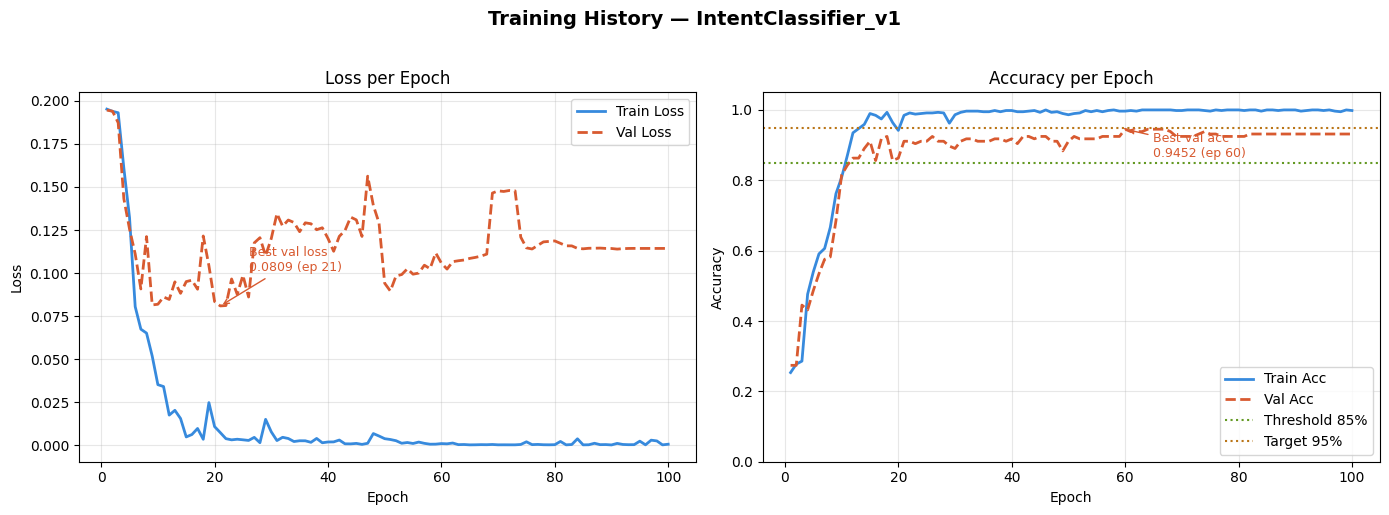

Plot disimpan: training_curves.png


In [95]:
# RUN VISUALIZATION

plot_training_curves(training_history)

In [96]:
# EVALUASI MODEL (Test Set)

# Load best model
best_model = tf.keras.models.load_model(
    'copilot_intent_model_best.keras',
    custom_objects={
        'AttentionPooling': AttentionPooling,
        'FocalLoss': FocalLoss
    }
)

# Prediksi pada test set
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Metrik Utama
test_acc = np.mean(y_pred == y_test)
target_names = ['Admin & Akun', 'Capstone & Reporting', 'Materi & Kurikulum', 'Teknis/Lain-lain']

evaluation_summary = f"""
EVALUASI PERFORMA MODEL (TEST SET)

Accuracy Global : {test_acc:.4f} ({test_acc * 100:.2f}%)

Classification Report Detail:"""

print(evaluation_summary)
print(classification_report(y_test, y_pred, target_names=target_names))


EVALUASI PERFORMA MODEL (TEST SET)

Accuracy Global : 0.9452 (94.52%)

Classification Report Detail:
                      precision    recall  f1-score   support

        Admin & Akun       0.94      1.00      0.97        34
Capstone & Reporting       0.93      1.00      0.96        38
  Materi & Kurikulum       0.92      1.00      0.96        34
    Teknis/Lain-lain       1.00      0.80      0.89        40

            accuracy                           0.95       146
           macro avg       0.95      0.95      0.95       146
        weighted avg       0.95      0.95      0.94       146



In [97]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"{'':20s}", end='')
for name in target_names:
    print(f"{name[:12]:>14}", end='')
print()
for i, row in enumerate(cm):
    print(f"{target_names[i][:20]:20s}", end='')
    for val in row:
        print(f"{val:>14}", end='')
    print()

Confusion Matrix:
                      Admin & Akun  Capstone & R  Materi & Kur  Teknis/Lain-
Admin & Akun                    34             0             0             0
Capstone & Reporting             0            38             0             0
Materi & Kurikulum               0             0            34             0
Teknis/Lain-lain                 2             3             3            32


In [98]:
# ERROR ANALYSIS — LABEL 3

"""
Menganalisis 8 sampel yang salah diklasifikasi dari Label 3.
Dari confusion matrix:
  - 2 sampel → salah prediksi ke Label 0 (Admin & Akun)
  - 3 sampel → salah prediksi ke Label 1 (Capstone & Reporting)
  - 3 sampel → salah prediksi ke Label 2 (Materi & Kurikulum)
"""

LABEL_NAMES = {
    0: 'Administrasi & Akun',
    1: 'Capstone & Reporting',
    2: 'Materi & Kurikulum',
    3: 'Teknis/Lain-lain'
}

# Gabungkan X_test dengan y_test dan y_pred untuk analisis
df_test_analysis = pd.DataFrame({
    'Pertanyaan_Clean': [
        tokenizer.sequences_to_texts([seq.tolist()])[0]
        for seq in X_test
    ],
    'y_true': y_test,
    'y_pred': y_pred,
    'confidence': np.max(y_pred_proba, axis=1)
})

# Filter: hanya yang true label = 3 dan prediksi salah
misclassified_label3 = df_test_analysis[
    (df_test_analysis['y_true'] == 3) &
    (df_test_analysis['y_pred'] != 3)
].copy()

misclassified_label3['pred_label_name'] = misclassified_label3['y_pred'].map(LABEL_NAMES)

print(f"Total salah klasifikasi Label 3: {len(misclassified_label3)} sampel\n")
print(f"{'No':>3} | {'Diprediksi ke':^25} | {'Conf':>6} | Teks (cleaned)")
print("-" * 90)
for i, (_, row) in enumerate(misclassified_label3.iterrows(), 1):
    print(f"{i:>3} | {row['pred_label_name']:<25} | {row['confidence']*100:>5.1f}% | {row['Pertanyaan_Clean'][:50]}")

# Breakdown per salah prediksi
print("\nBreakdown salah prediksi Label 3:")
breakdown = misclassified_label3['pred_label_name'].value_counts()
for cat, count in breakdown.items():
    print(f"  → {cat}: {count} sampel")

Total salah klasifikasi Label 3: 8 sampel

 No |       Diprediksi ke       |   Conf | Teks (cleaned)
------------------------------------------------------------------------------------------
  1 | Capstone & Reporting      |  96.9% | nilai para peserta dibagikan dilihat secara publik
  2 | Capstone & Reporting      |  97.8% | kan lupa absen capstone brief mengumpulkan abstrac
  3 | Administrasi & Akun       |  99.8% | sertifikat coding camp berlaku tahun tetap konvers
  4 | Materi & Kurikulum        |  80.9% | dikirim sendiri terus nilai ama tim dicoding langs
  5 | Capstone & Reporting      |  97.8% | izin bertanya mendaftarkan tim validasi email tim 
  6 | Materi & Kurikulum        |  86.3% | perbedaan poin apa deskripsi ketiganya mirip <OOV>
  7 | Administrasi & Akun       |  81.8% | maaf oot tanya main kantor dicoding <OOV> <OOV> <O
  8 | Materi & Kurikulum        |  92.1% | guys bertanya tujuan daskboard apa gunanya lanjuta

Breakdown salah prediksi Label 3:
  → Capstone & Report

In [99]:
# CONFIDENCE DISTRIBUTION — LABEL 3

"""
Membandingkan distribusi confidence untuk prediksi benar vs salah di Label 3.
Prediksi salah dengan confidence tinggi = model overconfident → perlu dilihat
apakah keyword lexicon Label 3 terlalu overlap dengan label lain.
"""

correct_label3 = df_test_analysis[
    (df_test_analysis['y_true'] == 3) &
    (df_test_analysis['y_pred'] == 3)
]['confidence']

wrong_label3 = df_test_analysis[
    (df_test_analysis['y_true'] == 3) &
    (df_test_analysis['y_pred'] != 3)
]['confidence']

confidence_report = f"""Confidence — prediksi BENAR (Label 3):
  Mean : {correct_label3.mean():.4f}
  Min  : {correct_label3.min():.4f}
  Max  : {correct_label3.max():.4f}

Confidence — prediksi SALAH (Label 3):
  Mean : {wrong_label3.mean():.4f}
  Min  : {wrong_label3.min():.4f}
  Max  : {wrong_label3.max():.4f}

Catatan: Jika confidence salah prediksi > 0.7,
artinya model overconfident → pertimbangkan tambah keyword LEXICON[3]
atau kurangi overlap keyword antar label."""

print(confidence_report)

Confidence — prediksi BENAR (Label 3):
  Mean : 0.9401
  Min  : 0.4589
  Max  : 0.9998

Confidence — prediksi SALAH (Label 3):
  Mean : 0.9169
  Min  : 0.8092
  Max  : 0.9983

Catatan: Jika confidence salah prediksi > 0.7,
artinya model overconfident → pertimbangkan tambah keyword LEXICON[3]
atau kurangi overlap keyword antar label.


In [100]:
# ROOT CAUSE SUMMARY

"""
Ringkasan temuan error analysis untuk laporan teknis.
"""

root_cause_report = f"""
ROOT CAUSE ANALYSIS — Label 3 (Teknis/Lain-lain)

Recall  : 0.80  (8 dari 40 sampel salah prediksi)
Distribusi error:
  → 2 sampel → Label 0 (Admin & Akun)
     Kemungkinan penyebab: keyword 'dashboard', 'email',
     'validasi' muncul di kedua label
  → 3 sampel → Label 1 (Capstone & Reporting)
     Kemungkinan penyebab: keyword 'tim', 'registrasi',
     'daftar' overlap dengan konteks capstone
  → 3 sampel → Label 2 (Materi & Kurikulum)
     Kemungkinan penyebab: keyword 'abstrak', 'kelas',
     'submission' muncul di konteks ILT/kehadiran

Rekomendasi:
  1. Tambah keyword lebih spesifik ke LEXICON[3]
     mis: 'status absen', 'banding kehadiran', 'kode sesi ilt'
  2. Hapus keyword yang terlalu umum dari LEXICON[3]
     mis: 'dashboard', 'email', 'registrasi'
  3. Pertimbangkan tambah data augmentasi khusus Label 3
     karena ini label mayoritas yang paling beragam konteksnya"""

print(root_cause_report)


ROOT CAUSE ANALYSIS — Label 3 (Teknis/Lain-lain)

Recall  : 0.80  (8 dari 40 sampel salah prediksi)
Distribusi error:
  → 2 sampel → Label 0 (Admin & Akun)
     Kemungkinan penyebab: keyword 'dashboard', 'email',
     'validasi' muncul di kedua label
  → 3 sampel → Label 1 (Capstone & Reporting)
     Kemungkinan penyebab: keyword 'tim', 'registrasi',
     'daftar' overlap dengan konteks capstone
  → 3 sampel → Label 2 (Materi & Kurikulum)
     Kemungkinan penyebab: keyword 'abstrak', 'kelas',
     'submission' muncul di konteks ILT/kehadiran

Rekomendasi:
  1. Tambah keyword lebih spesifik ke LEXICON[3]
     mis: 'status absen', 'banding kehadiran', 'kode sesi ilt'
  2. Hapus keyword yang terlalu umum dari LEXICON[3]
     mis: 'dashboard', 'email', 'registrasi'
  3. Pertimbangkan tambah data augmentasi khusus Label 3
     karena ini label mayoritas yang paling beragam konteksnya


In [101]:
# TOKENIZER EXPORT

"""
Simpan tokenizer ke JSON agar bisa di-load ulang tanpa retraining.
Tanpa ini, inference di environment lain akan menghasilkan
index kata yang berbeda dan prediksi yang salah.
"""

import json

tokenizer_config = {
    'word_index': tokenizer.word_index,
    'config': {
        'num_words': VOCAB_SIZE,
        'oov_token': OOV_TOK,
        'max_length': MAX_LENGTH,
        'padding': PADDING_TYPE,
        'truncating': TRUNC_TYPE,
        'embedding_dim': EMBEDDING_DIM
    }
}

# Simpan file ke disk
with open('tokenizer_config.json', 'w', encoding='utf-8') as f:
    json.dump(tokenizer_config, f, ensure_ascii=False, indent=2)

# Verifikasi langsung bisa di-load ulang
with open('tokenizer_config.json', 'r', encoding='utf-8') as f:
    loaded_config = json.load(f)

tokenizer_report = f"""Asset Tokenizer Berhasil Diekspor!
File disimpan   : tokenizer_config.json
Total Vocab     : {len(tokenizer.word_index):,} kata

[Verifikasi Load Sukses]
Kata Terbaca    : {len(loaded_config['word_index']):,} kata
Config Params   : {loaded_config['config']}"""

print(tokenizer_report)

Asset Tokenizer Berhasil Diekspor!
File disimpan   : tokenizer_config.json
Total Vocab     : 1,660 kata

[Verifikasi Load Sukses]
Kata Terbaca    : 1,660 kata
Config Params   : {'num_words': 3000, 'oov_token': '<OOV>', 'max_length': 80, 'padding': 'post', 'truncating': 'post', 'embedding_dim': 64}


In [102]:
# MODEL EXPORT VERIFICATION

"""
Verifikasi file .keras bisa di-load ulang dengan custom objects.
Ini simulasi kondisi production: model di-load fresh tanpa history training.
"""

import os

MODEL_PATH = 'copilot_intent_model_best.keras'

# Cek file ada
assert os.path.exists(MODEL_PATH), f"File tidak ditemukan: {MODEL_PATH}"
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"File ditemukan: {MODEL_PATH} ({size_mb:.2f} MB)\n")

# Load ulang dari disk (simulasi cold start)
production_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'AttentionPooling': AttentionPooling,
        'FocalLoss': FocalLoss
    }
)

# Sanity check output shape
dummy_input = np.zeros((1, MAX_LENGTH), dtype='int32')
dummy_output = production_model.predict(dummy_input, verbose=0)
assert dummy_output.shape == (1, 4), "Output shape tidak sesuai!"

verification_report = f"""Model berhasil di-load ulang (Cold Start Simulation).
Input shape  : (batch, {MAX_LENGTH})
Output shape : {dummy_output.shape} → 4 kelas
Sum softmax  : {dummy_output.sum():.6f} (harus ≈ 1.0)"""

print(verification_report)

File ditemukan: copilot_intent_model_best.keras (1.07 MB)

Model berhasil di-load ulang (Cold Start Simulation).
Input shape  : (batch, 80)
Output shape : (1, 4) → 4 kelas
Sum softmax  : 1.000000 (harus ≈ 1.0)


In [103]:
# PRODUCTION INFERENCE MODULE

"""
Versi bersih dari predict_intent() yang siap dipakai AI API.
Perubahan dari versi development:
- Input validation & error handling
- Response format konsisten (selalu return dict dengan field lengkap)
- Confidence threshold: jika < 0.5 → flag sebagai low confidence
- Batch prediction support
"""

LABEL_NAMES = {
    0: 'Administrasi & Akun',
    1: 'Capstone & Reporting',
    2: 'Materi & Kurikulum',
    3: 'Teknis/Lain-lain'
}

CONFIDENCE_THRESHOLD = 0.50


def preprocess(text: str) -> tuple:
    """Preprocessing pipeline: clean → tokenize → pad."""
    cleaned = clean_text(str(text).strip())
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        seq,
        maxlen=MAX_LENGTH,
        padding=PADDING_TYPE,
        truncating=TRUNC_TYPE
    )
    return padded, cleaned


def predict_single(text: str, model=production_model) -> dict:
    """
    Prediksi intent untuk satu pertanyaan.
    """
    # Validasi input
    if not text or not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'status': 'error',
            'input': text,
            'cleaned_text': '',
            'label': None,
            'category': None,
            'confidence': 0.0,
            'all_scores': {},
            'message': 'Input tidak valid atau kosong.'
        }

    try:
        padded, cleaned = preprocess(text)
        proba = model.predict(padded, verbose=0)[0]
        label = int(np.argmax(proba))
        confidence = float(np.max(proba))

        status = 'ok' if confidence >= CONFIDENCE_THRESHOLD else 'low_confidence'
        message = '' if status == 'ok' else (
            f'Confidence rendah ({confidence:.2%}). '
            'Pertanyaan mungkin ambigu atau di luar domain.'
        )

        return {
            'status': status,
            'input': text,
            'cleaned_text': cleaned,
            'label': label,
            'category': LABEL_NAMES[label],
            'confidence': round(confidence, 4),
            'all_scores': {
                LABEL_NAMES[i]: round(float(p), 4)
                for i, p in enumerate(proba)
            },
            'message': message
        }

    except Exception as e:
        return {
            'status': 'error',
            'input': text,
            'cleaned_text': '',
            'label': None,
            'category': None,
            'confidence': 0.0,
            'all_scores': {},
            'message': f'Inference error: {str(e)}'
        }


def predict_batch(texts: list, model=production_model) -> list:
    """
    Prediksi intent untuk banyak pertanyaan sekaligus.
    Lebih efisien dari memanggil predict_single() berulang kali.
    """
    if not texts or not isinstance(texts, list):
        return []

    results = []
    cleaned_texts = []
    valid_indices = []

    for i, text in enumerate(texts):
        if text and isinstance(text, str) and len(text.strip()) > 0:
            _, cleaned = preprocess(text)
            cleaned_texts.append(cleaned)
            valid_indices.append(i)
        else:
            results.append({
                'status': 'error', 'input': text,
                'label': None, 'category': None,
                'confidence': 0.0, 'message': 'Input tidak valid.'
            })

    if cleaned_texts:
        seqs = tokenizer.texts_to_sequences(cleaned_texts)
        padded = pad_sequences(
            seqs, maxlen=MAX_LENGTH,
            padding=PADDING_TYPE, truncating=TRUNC_TYPE
        )
        probas = model.predict(padded, verbose=0)

        for idx, proba in zip(valid_indices, probas):
            label = int(np.argmax(proba))
            confidence = float(np.max(proba))
            results.insert(idx, {
                'status': 'ok' if confidence >= CONFIDENCE_THRESHOLD else 'low_confidence',
                'input': texts[idx],
                'label': label,
                'category': LABEL_NAMES[label],
                'confidence': round(confidence, 4),
                'all_scores': {
                    LABEL_NAMES[i]: round(float(p), 4)
                    for i, p in enumerate(proba)
                },
                'message': '' if confidence >= CONFIDENCE_THRESHOLD else
                    f'Confidence rendah ({confidence:.2%}).'
            })

    return results

inference_status = f"""[MODULE READY] Production Inference Module initialized.
Confidence Threshold : {CONFIDENCE_THRESHOLD:.2f} ({(CONFIDENCE_THRESHOLD * 100):.0f}%)
Functions available  : preprocess(), predict_single(), predict_batch()"""

print(inference_status)


[MODULE READY] Production Inference Module initialized.
Confidence Threshold : 0.50 (50%)
Functions available  : preprocess(), predict_single(), predict_batch()


In [104]:
# INFERENCE TEST

test_cases = [
    # Normal cases
    "kak izin bertanyaa, waktu ilt english aku hadir tapi telat kak, apa bisa diaju banding?? aku ada bukti screenshotnya kak",
    "info link untuk pembuatan abstrak jika tidak melakukan absensi finansial literasi?",
    "Halo kak , izin bertanya pada sesi coding camp talk 2 status saya absent , , itu kira kira kegiatan di tanggal berapa ya ? dan  kegiatan apa ? , terimakasih",
    "Hallo kak, aku izin bertanya terkait dataset untuk capstone, apakah diperbolehkan menggunakan data sintesis atau dummy dari ai kak? soalnya udah nyari di kaggle dan website data lainnya nggak ketemu yang cocok, kalau ketemu yang cocok dikit juga",
    # Edge cases
    "",                          # input kosong
    "???",                       # teks tidak bermakna
]

table_rows = []
for i, q in enumerate(test_cases, 1):
    r = predict_single(q)
    cat  = r['category'] or '-'
    conf = f"{r['confidence']*100:.1f}%" if r['confidence'] else '-'
    inp  = (q[:35] + '...') if len(q) > 35 else (q if q else '(kosong)')

    table_rows.append(f"{i:>3} | {r['status']:<15} | {cat:<25} | {conf:>6} | {inp}")

    if r['status'] in ('error', 'low_confidence'):
        table_rows.append(f"     ↳ {r['message']}")

test_report = f"""
INFERENCE PIPELINE SUITE TEST

{'No':>3} | {'Status':<15} | {'Kategori':<25} | {'Conf':>6} | Input
{"-" * 95}
{"\n".join(table_rows)}


Contoh Response JSON Lengkap (Kasus 1):"""

print(test_report)
pprint.pprint(predict_single(test_cases[0]))



INFERENCE PIPELINE SUITE TEST

 No | Status          | Kategori                  |   Conf | Input
-----------------------------------------------------------------------------------------------
  1 | ok              | Teknis/Lain-lain          |  98.7% | kak izin bertanyaa, waktu ilt engli...
  2 | ok              | Materi & Kurikulum        |  87.1% | info link untuk pembuatan abstrak j...
  3 | ok              | Teknis/Lain-lain          |  98.0% | Halo kak , izin bertanya pada sesi ...
  4 | ok              | Capstone & Reporting      |  97.9% | Hallo kak, aku izin bertanya terkai...
  5 | error           | -                         |      - | (kosong)
     ↳ Input tidak valid atau kosong.
  6 | ok              | Capstone & Reporting      |  97.6% | ???


Contoh Response JSON Lengkap (Kasus 1):
{'all_scores': {'Administrasi & Akun': 0.013,
                'Capstone & Reporting': 0.0002,
                'Materi & Kurikulum': 0.0,
                'Teknis/Lain-lain': 0.9868},
 'catego

In [105]:
# SAVE ALL PRODUCTION ARTIFACTS

"""
Daftar file yang perlu di-commit ke repo dan dikirim ke tim Full-Stack:
1. copilot_intent_model_best.keras  → model weights
2. tokenizer_config.json            → vocab & config
3. training_log.json                → audit trail training
"""

artifacts = [
    'copilot_intent_model_best.keras',
    'tokenizer_config.json',
    'training_log.json',
]

artifact_rows = []
for f in artifacts:
    exists = os.path.exists(f)
    size   = (os.path.getsize(f) / 1024) if exists else 0
    status = "OK" if exists else "MISSING"
    artifact_rows.append(f"  [{status:<7}] {f:<32} ({size:>6.1f} KB)")

artifacts_report = f"""
PRODUCTION ARTIFACTS CHECKLIST


{"\n".join(artifact_rows)}

Semua artifact siap untuk diserahkan ke tim Full-Stack & AI API!"""

print(artifacts_report)



PRODUCTION ARTIFACTS CHECKLIST


  [OK     ] copilot_intent_model_best.keras  (1095.5 KB)
  [OK     ] tokenizer_config.json            (  33.5 KB)
  [OK     ] training_log.json                (  21.0 KB)

Semua artifact siap untuk diserahkan ke tim Full-Stack & AI API!
